# Korean Stock Market Regime Analysis
## Evaluating Principal-Protected Structured Products (ELD) Rationality

**Analytical Framework:** Market Regime → Forward Return Probability → Product Payoff → Expected Return

This notebook implements a complete regime analysis of the Korean stock market (KOSPI) to determine whether principal-protected structured products like ELD are rational choices under the current market regime.

## 0. Setup and Configuration

In [6]:
# ============================================================================
# SECTION 0: IMPORTS & CONFIGURATION
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime, date
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, confusion_matrix
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")
print(f"✓ Analysis Date: {date.today()}")

✓ All libraries imported successfully
✓ Analysis Date: 2026-03-03


## 1. Data Acquisition

In [9]:
# ============================================================================
# SECTION 1: DATA ACQUISITION
# ============================================================================
# Download daily KOSPI data from Yahoo Finance
# Period: 2000-01-01 to today
# Handles weekends/holidays automatically

ticker = "^KS11"  # KOSPI Index
start_date = "2000-01-01"
end_date = date.today().strftime('%Y-%m-%d')

print(f"Downloading KOSPI data from {start_date} to {end_date}...")
kospi = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Use only Adj Close for analysis
kospi_price = kospi[['Close']].copy()
kospi_price.columns = ['price']

# Remove any NaN values
kospi_price = kospi_price.dropna()

print(f"✓ Downloaded {len(kospi_price)} trading days")
print(f"✓ Date range: {kospi_price.index[0].date()} to {kospi_price.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(kospi_price.head())
print(f"\nLast 5 rows:")
print(kospi_price.tail())

✓ Downloaded 6441 trading days
✓ Date range: 2000-01-04 to 2026-02-27

First 5 rows:
                  price
Date                   
2000-01-04  1059.040039
2000-01-05   986.309998
2000-01-06   960.789978
2000-01-07   948.650024
2000-01-10   987.239990

Last 5 rows:
                  price
Date                   
2026-02-23  5846.089844
2026-02-24  5969.640137
2026-02-25  6083.859863
2026-02-26  6307.270020
2026-02-27  6244.129883


## 2. Feature Engineering for Regime Classification

In [10]:
# ============================================================================
# SECTION 2: FEATURE ENGINEERING
# ============================================================================
# Create daily features for regime classification:
# 1. Daily return (simple return)
# 2. 20-day annualized volatility (rolling std * sqrt(252))
# 3. Drawdown from peak (current price / peak - 1)
# 4. 1-month momentum (21-day return)
# 5. 3-month momentum (63-day return)

def create_features(df_price):
    """
    Create regime classification features from price data.
    
    Parameters:
    -----------
    df_price : pd.DataFrame
        DataFrame with 'price' column
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with features: daily_return, volatility_20d, drawdown, momentum_1m, momentum_3m
    """
    features = pd.DataFrame(index=df_price.index)
    
    # 1. Daily return
    features['daily_return'] = df_price['price'].pct_change()
    
    # 2. 20-day rolling volatility (annualized)
    features['volatility_20d'] = df_price['price'].pct_change().rolling(20).std() * np.sqrt(252)
    
    # 3. Drawdown from peak
    cummax = df_price['price'].expanding().max()
    features['drawdown'] = (df_price['price'] / cummax) - 1
    
    # 4. 1-month momentum (21 trading days)
    features['momentum_1m'] = df_price['price'].pct_change(21)
    
    # 5. 3-month momentum (63 trading days)
    features['momentum_3m'] = df_price['price'].pct_change(63)
    
    return features

features_df = create_features(kospi_price)

# Remove NaN rows (due to rolling window calculations)
features_df = features_df.dropna()

print(f"✓ Features created for {len(features_df)} observations")
print(f"\nFeature Statistics:")
print(features_df.describe().round(4))
print(f"\nFirst 5 rows of features:")
print(features_df.head())

✓ Features created for 6378 observations

Feature Statistics:
       daily_return  volatility_20d   drawdown  momentum_1m  momentum_3m
count     6378.0000       6378.0000  6378.0000    6378.0000    6378.0000
mean         0.0004          0.1964    -0.1717       0.0081       0.0227
std          0.0142          0.1116     0.1259       0.0643       0.1139
min         -0.1202          0.0458    -0.5574      -0.3725      -0.4227
25%         -0.0059          0.1211    -0.2375      -0.0267      -0.0412
50%          0.0007          0.1667    -0.1500       0.0090       0.0204
75%          0.0074          0.2307    -0.0795       0.0446       0.0811
max          0.1195          0.9114     0.0000       0.3024       0.6369

First 5 rows of features:
            daily_return  volatility_20d  drawdown  momentum_1m  momentum_3m
Date                                                                        
2000-04-04     -0.019234        0.311133 -0.216120    -0.087064    -0.216120
2000-04-06     -0.03109

## 3. Regime Classification - Method A: KMeans Clustering

Testing KMeans with different K values...
  K=2: Inertia=23169.71, Silhouette=0.3980
  K=3: Inertia=19644.39, Silhouette=0.2919
  K=4: Inertia=17521.89, Silhouette=0.2830
  K=5: Inertia=15827.43, Silhouette=0.1899
  K=6: Inertia=14475.13, Silhouette=0.1986
  K=7: Inertia=13579.58, Silhouette=0.1928
  K=8: Inertia=12812.49, Silhouette=0.1787

✓ Optimal K (by Silhouette): 2


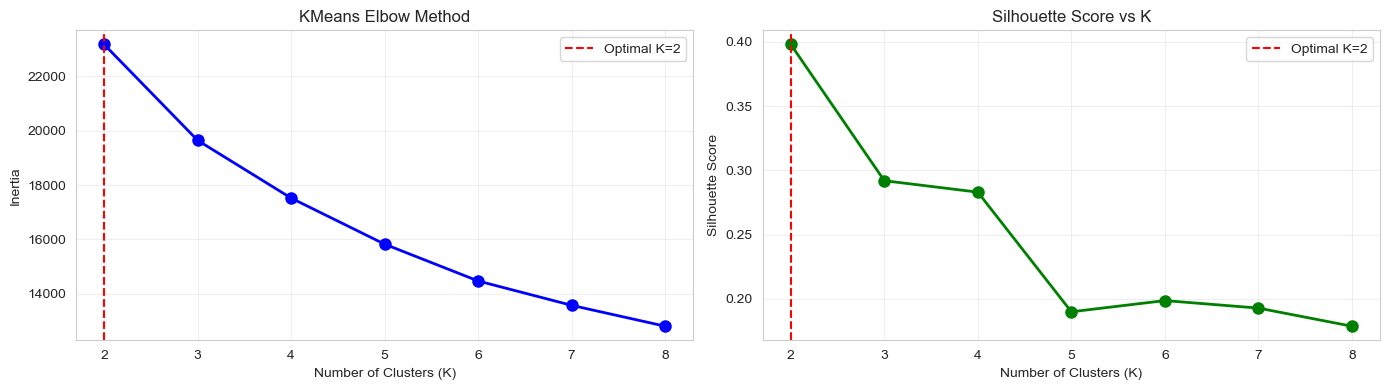


✓ KMeans regime distribution:
regime_kmeans
0    1294
1    5084
Name: count, dtype: int64


In [11]:
# ============================================================================
# SECTION 3A: KMEANS REGIME CLASSIFICATION
# ============================================================================
# Method: KMeans with Elbow method and Silhouette score
# Test K from 2 to 8, select optimal K based on Silhouette score

# Prepare data: standardize features
scaler_kmeans = StandardScaler()
features_scaled = scaler_kmeans.fit_transform(features_df)

# Elbow method + Silhouette score
inertias = []
silhouette_scores = []
K_range = range(2, 9)

print("Testing KMeans with different K values...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(features_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Select optimal K based on Silhouette score
optimal_k_kmeans = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal K (by Silhouette): {optimal_k_kmeans}")

# Train final KMeans model
kmeans_final = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
features_df['regime_kmeans'] = kmeans_final.fit_predict(features_scaled)

# Plot Elbow curve and Silhouette score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(optimal_k_kmeans, color='r', linestyle='--', label=f'Optimal K={optimal_k_kmeans}')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('KMeans Elbow Method')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(optimal_k_kmeans, color='r', linestyle='--', label=f'Optimal K={optimal_k_kmeans}')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ KMeans regime distribution:")
print(features_df['regime_kmeans'].value_counts().sort_index())

## 3b. Regime Classification - Method B: Hidden Markov Model

Training HMM models with different state counts...
  n_states=2: BIC=71330.09, AIC=71174.59
  n_states=3: BIC=64615.29, AIC=64358.39
  n_states=4: BIC=60024.21, AIC=59652.37
  n_states=5: BIC=57165.86, AIC=56665.58
  n_states=6: BIC=55124.60, AIC=54482.34

✓ Optimal states (by BIC): 6


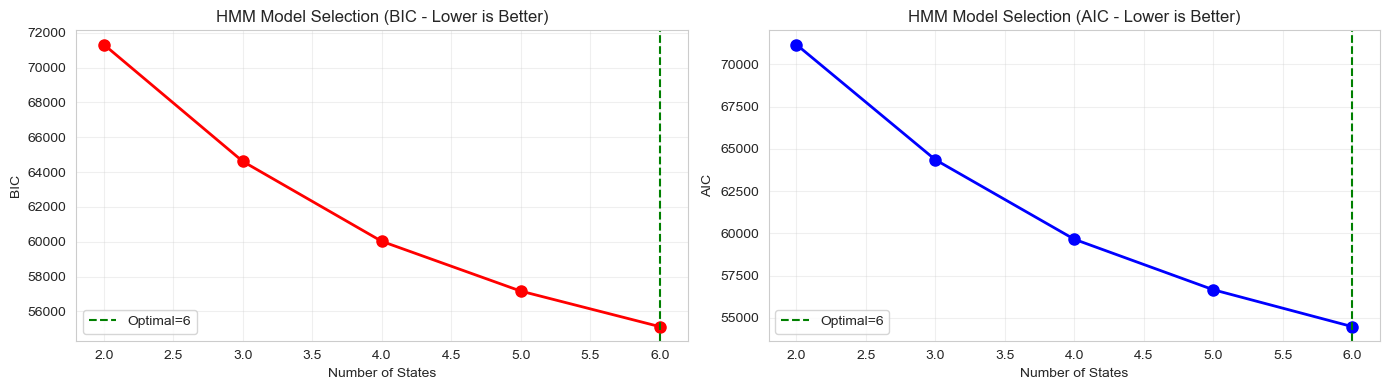


✓ HMM regime distribution:
regime_hmm
0    1133
1    1403
2     991
3    1153
4     772
5     926
Name: count, dtype: int64


In [12]:
# ============================================================================
# SECTION 3B: HIDDEN MARKOV MODEL (GaussianHMM) REGIME CLASSIFICATION
# ============================================================================
# Method: HMM with state selection via BIC/AIC
# Test 2~6 states, select best based on BIC

print("Training HMM models with different state counts...")
hmm_models = {}
bic_scores = []
aic_scores = []
n_states_range = range(2, 7)

for n_states in n_states_range:
    hmm = GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=1000, random_state=42)
    hmm.fit(features_scaled)
    hmm_models[n_states] = hmm
    
    bic = hmm.bic(features_scaled)
    aic = hmm.aic(features_scaled)
    bic_scores.append(bic)
    aic_scores.append(aic)
    
    print(f"  n_states={n_states}: BIC={bic:.2f}, AIC={aic:.2f}")

# Select optimal states based on BIC (lower is better)
optimal_states_hmm = n_states_range[np.argmin(bic_scores)]
print(f"\n✓ Optimal states (by BIC): {optimal_states_hmm}")

# Get regimes from optimal HMM
hmm_final = hmm_models[optimal_states_hmm]
features_df['regime_hmm'] = hmm_final.predict(features_scaled)

# Plot BIC and AIC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(n_states_range, bic_scores, 'ro-', linewidth=2, markersize=8)
ax1.axvline(optimal_states_hmm, color='g', linestyle='--', label=f'Optimal={optimal_states_hmm}')
ax1.set_xlabel('Number of States')
ax1.set_ylabel('BIC')
ax1.set_title('HMM Model Selection (BIC - Lower is Better)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(n_states_range, aic_scores, 'bo-', linewidth=2, markersize=8)
ax2.axvline(optimal_states_hmm, color='g', linestyle='--', label=f'Optimal={optimal_states_hmm}')
ax2.set_xlabel('Number of States')
ax2.set_ylabel('AIC')
ax2.set_title('HMM Model Selection (AIC - Lower is Better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ HMM regime distribution:")
print(features_df['regime_hmm'].value_counts().sort_index())

## 4. Regime Transition Analysis

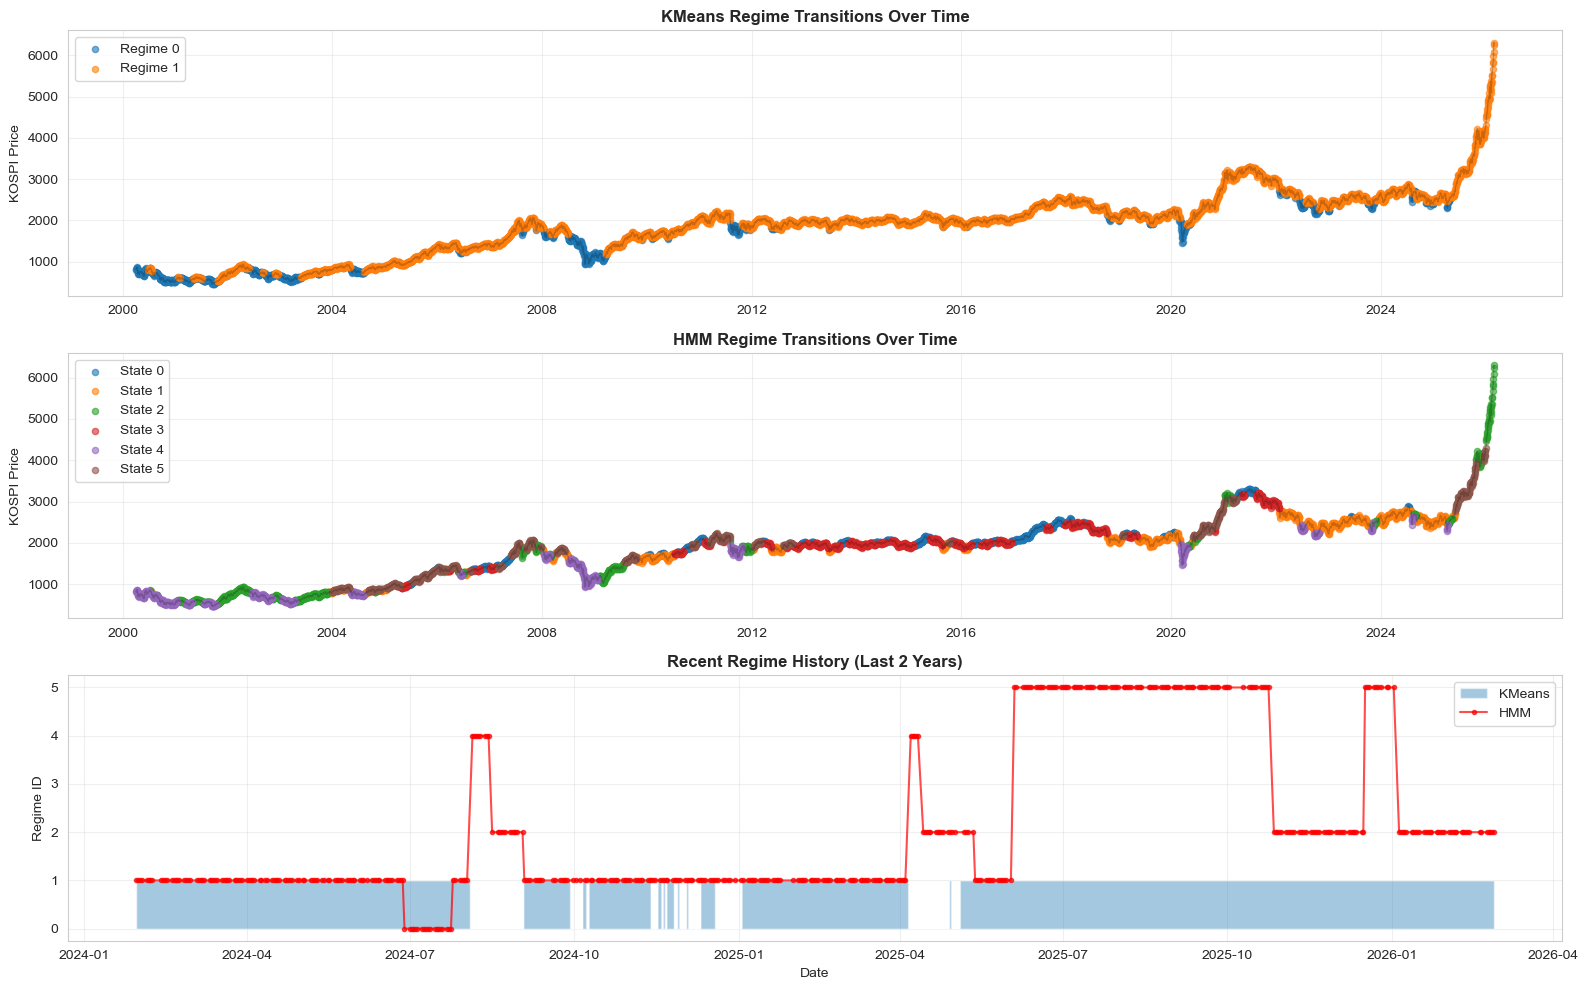


CURRENT REGIME STATUS (Last 20-60 days)

--- Last 20 Trading Days ---
KMeans Regime Distribution:
regime_kmeans
1    20
Name: count, dtype: int64
Most common regime: 1

HMM State Distribution:
regime_hmm
2    20
Name: count, dtype: int64
Most common state: 2

--- Last 60 Trading Days ---
KMeans Regime Distribution:
regime_kmeans
1    60
Name: count, dtype: int64

HMM State Distribution:
regime_hmm
2    50
5    10
Name: count, dtype: int64

--- Latest Date: 2026-02-27 ---
KMeans Current Regime: 1
HMM Current State: 2


In [13]:
# ============================================================================
# SECTION 4: REGIME TRANSITION ANALYSIS
# ============================================================================
# Visualize regime transitions over time and show recent regimes

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Prepare price data aligned with features
price_aligned = kospi_price.loc[features_df.index]

# Plot 1: Price with KMeans regimes
ax = axes[0]
for regime in sorted(features_df['regime_kmeans'].unique()):
    mask = features_df['regime_kmeans'] == regime
    ax.scatter(features_df.index[mask], price_aligned.loc[mask, 'price'], 
              label=f'Regime {regime}', alpha=0.6, s=20)
ax.plot(features_df.index, price_aligned['price'], 'k-', alpha=0.2, linewidth=1)
ax.set_ylabel('KOSPI Price')
ax.set_title('KMeans Regime Transitions Over Time', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Price with HMM regimes
ax = axes[1]
for regime in sorted(features_df['regime_hmm'].unique()):
    mask = features_df['regime_hmm'] == regime
    ax.scatter(features_df.index[mask], price_aligned.loc[mask, 'price'], 
              label=f'State {regime}', alpha=0.6, s=20)
ax.plot(features_df.index, price_aligned['price'], 'k-', alpha=0.2, linewidth=1)
ax.set_ylabel('KOSPI Price')
ax.set_title('HMM Regime Transitions Over Time', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 3: Regime time series (last 2 years for clarity)
last_2y = features_df.tail(252*2)
ax = axes[2]
ax.fill_between(last_2y.index, 0, last_2y['regime_kmeans'], alpha=0.4, label='KMeans', step='mid')
ax.plot(last_2y.index, last_2y['regime_hmm'], 'r-', marker='o', markersize=3, label='HMM', alpha=0.7)
ax.set_ylabel('Regime ID')
ax.set_xlabel('Date')
ax.set_title('Recent Regime History (Last 2 Years)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CURRENT REGIME STATUS (Last 20-60 days)")
print("="*80)

recent_20 = features_df.tail(20)
recent_60 = features_df.tail(60)

print("\n--- Last 20 Trading Days ---")
print(f"KMeans Regime Distribution:")
print(recent_20['regime_kmeans'].value_counts().sort_index())
print(f"Most common regime: {recent_20['regime_kmeans'].mode()[0]}")
print(f"\nHMM State Distribution:")
print(recent_20['regime_hmm'].value_counts().sort_index())
print(f"Most common state: {recent_20['regime_hmm'].mode()[0]}")

print("\n--- Last 60 Trading Days ---")
print(f"KMeans Regime Distribution:")
print(recent_60['regime_kmeans'].value_counts().sort_index())
print(f"\nHMM State Distribution:")
print(recent_60['regime_hmm'].value_counts().sort_index())

print(f"\n--- Latest Date: {features_df.index[-1].date()} ---")
print(f"KMeans Current Regime: {features_df['regime_kmeans'].iloc[-1]}")
print(f"HMM Current State: {features_df['regime_hmm'].iloc[-1]}")

## 5. Regime Comparison: KMeans vs HMM

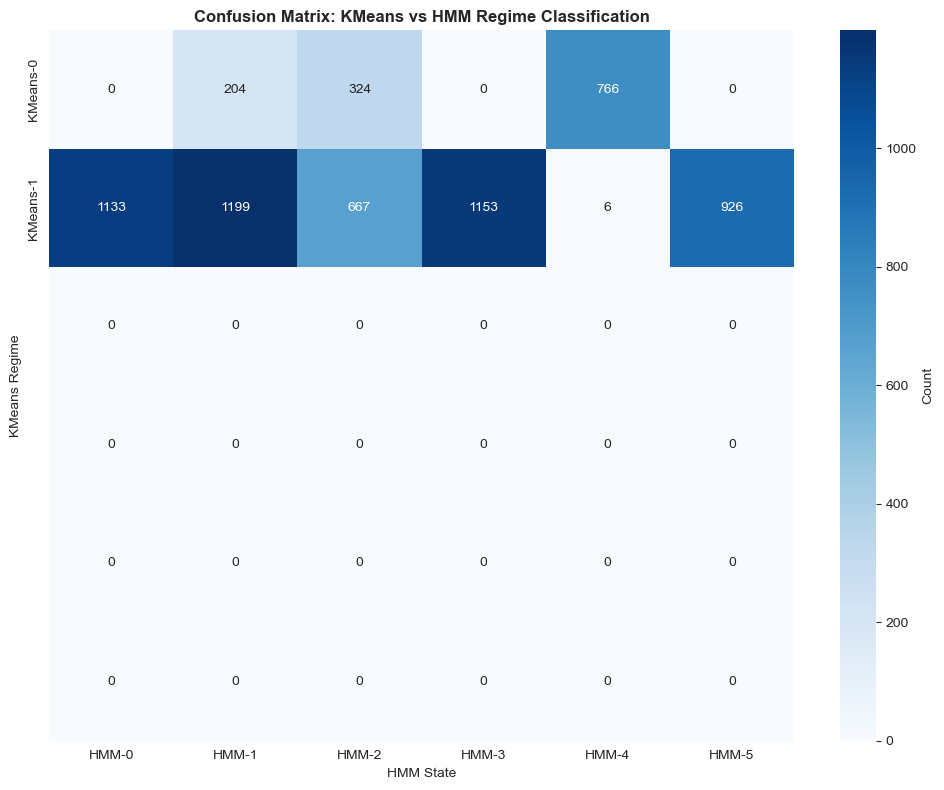

Confusion Matrix (KMeans rows × HMM columns):
[[   0  204  324    0  766    0]
 [1133 1199  667 1153    6  926]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]]

Diagonal agreement rate: 18.80%
Spearman correlation between KMeans and HMM: -0.2232

REGIME CHARACTERISTICS COMPARISON

--- KMeans Regime Statistics ---

Regime 0 (n=1294):
  Avg Daily Return:       -0.276%
  Volatility (std):       34.478%
  Avg Drawdown:          -33.581%
  Avg 1M Momentum:        -4.876%
  Avg 3M Momentum:        -9.520%

Regime 1 (n=5084):
  Avg Daily Return:        0.122%
  Volatility (std):       15.868%
  Avg Drawdown:          -12.993%
  Avg 1M Momentum:         2.264%
  Avg 3M Momentum:         5.269%

--- HMM State Statistics ---

State 0 (n=1133):
  Avg Daily Return:        0.107%
  Volatility (std):       10.046%
  Avg Drawdown:           -6.988%
  Avg 1M Momentum:         3.006%
  Avg 3M Momentum:         5.620%



In [14]:
# ============================================================================
# SECTION 5: REGIME MODEL COMPARISON
# ============================================================================
# Compare KMeans and HMM regimes using confusion matrix and correlation

# Align regime labels for comparison (map to best matching regime)
# This is useful when regime numbering differs between methods
from scipy.optimize import linear_sum_assignment

# Create confusion matrix
cm = confusion_matrix(features_df['regime_kmeans'], features_df['regime_hmm'])

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=[f'HMM-{i}' for i in sorted(features_df['regime_hmm'].unique())],
            yticklabels=[f'KMeans-{i}' for i in sorted(features_df['regime_kmeans'].unique())],
            cbar_kws={'label': 'Count'})
ax.set_xlabel('HMM State')
ax.set_ylabel('KMeans Regime')
ax.set_title('Confusion Matrix: KMeans vs HMM Regime Classification', fontweight='bold')
plt.tight_layout()
plt.show()

print("Confusion Matrix (KMeans rows × HMM columns):")
print(cm)
print(f"\nDiagonal agreement rate: {np.trace(cm) / np.sum(cm) * 100:.2f}%")

# Calculate regime correlation
regime_corr = features_df[['regime_kmeans', 'regime_hmm']].corr().iloc[0, 1]
print(f"Spearman correlation between KMeans and HMM: {regime_corr:.4f}")

# Compare regime characteristics
print("\n" + "="*80)
print("REGIME CHARACTERISTICS COMPARISON")
print("="*80)

print("\n--- KMeans Regime Statistics ---")
for regime in sorted(features_df['regime_kmeans'].unique()):
    regime_data = features_df[features_df['regime_kmeans'] == regime]
    print(f"\nRegime {regime} (n={len(regime_data)}):")
    print(f"  Avg Daily Return:      {regime_data['daily_return'].mean()*100:7.3f}%")
    print(f"  Volatility (std):      {regime_data['volatility_20d'].mean()*100:7.3f}%")
    print(f"  Avg Drawdown:          {regime_data['drawdown'].mean()*100:7.3f}%")
    print(f"  Avg 1M Momentum:       {regime_data['momentum_1m'].mean()*100:7.3f}%")
    print(f"  Avg 3M Momentum:       {regime_data['momentum_3m'].mean()*100:7.3f}%")

print("\n--- HMM State Statistics ---")
for state in sorted(features_df['regime_hmm'].unique()):
    state_data = features_df[features_df['regime_hmm'] == state]
    print(f"\nState {state} (n={len(state_data)}):")
    print(f"  Avg Daily Return:      {state_data['daily_return'].mean()*100:7.3f}%")
    print(f"  Volatility (std):      {state_data['volatility_20d'].mean()*100:7.3f}%")
    print(f"  Avg Drawdown:          {state_data['drawdown'].mean()*100:7.3f}%")
    print(f"  Avg 1M Momentum:       {state_data['momentum_1m'].mean()*100:7.3f}%")
    print(f"  Avg 3M Momentum:       {state_data['momentum_3m'].mean()*100:7.3f}%")

## 6. Forward Return Analysis by Regime

In [15]:
# ============================================================================
# SECTION 6: FORWARD RETURN ANALYSIS
# ============================================================================
# Calculate 3-month and 6-month forward returns for each regime
# Extract distribution statistics and tail probabilities

def calculate_forward_returns(price_series, forward_periods=[63, 126]):
    """
    Calculate forward returns for specified periods.
    
    Parameters:
    -----------
    price_series : pd.Series
        Price time series
    forward_periods : list
        List of periods (in days) for forward returns
    
    Returns:
    --------
    dict
        Dictionary with forward returns for each period
    """
    returns_dict = {}
    for period in forward_periods:
        # Forward return: calculate return that WOULD BE achieved
        # if you bought today at today's price
        forward_price = price_series.shift(-period)
        forward_ret = (forward_price / price_series) - 1
        returns_dict[f'{period}d_return'] = forward_ret
    return returns_dict

# Calculate forward returns
forward_returns = calculate_forward_returns(kospi_price['price'], forward_periods=[63, 126])
for col, series in forward_returns.items():
    features_df[col] = series

# Remove rows where forward return cannot be calculated
features_df_with_forward = features_df.dropna()

print(f"✓ Forward returns calculated for {len(features_df_with_forward)} observations")
print(f"\nForward Return Statistics (All Data):")
print(features_df_with_forward[['63d_return', '126d_return']].describe().round(4))

# KMEANS: Forward return analysis by regime
print("\n" + "="*80)
print("FORWARD RETURNS BY KMEANS REGIME")
print("="*80)

kmeans_forward_stats = {}
for regime in sorted(features_df_with_forward['regime_kmeans'].unique()):
    regime_data = features_df_with_forward[features_df_with_forward['regime_kmeans'] == regime]
    returns_3m = regime_data['63d_return']
    returns_6m = regime_data['126d_return']
    
    # Calculate statistics
    stats = {
        'count': len(regime_data),
        '3m_mean': returns_3m.mean(),
        '3m_median': returns_3m.median(),
        '3m_std': returns_3m.std(),
        '3m_skew': skew(returns_3m.dropna()),
        '3m_kurt': kurtosis(returns_3m.dropna()),
        '6m_mean': returns_6m.mean(),
        '6m_median': returns_6m.median(),
        '6m_std': returns_6m.std(),
        '6m_skew': skew(returns_6m.dropna()),
        '6m_kurt': kurtosis(returns_6m.dropna()),
        '3m_prob_loss15': (returns_3m < -0.15).sum() / len(returns_3m),  # P(R < -15%)
        '3m_prob_tail20': (abs(returns_3m) > 0.20).sum() / len(returns_3m),  # P(|R| > 20%)
        '6m_prob_loss15': (returns_6m < -0.15).sum() / len(returns_6m),
        '6m_prob_tail20': (abs(returns_6m) > 0.20).sum() / len(returns_6m),
    }
    kmeans_forward_stats[regime] = stats
    
    print(f"\nKMeans Regime {regime} (n={len(regime_data)} observations):")
    print(f"  3-Month Forward Return:")
    print(f"    Mean:              {stats['3m_mean']*100:7.3f}%")
    print(f"    Median:            {stats['3m_median']*100:7.3f}%")
    print(f"    Std Dev:           {stats['3m_std']*100:7.3f}%")
    print(f"    Skewness:          {stats['3m_skew']:7.3f}")
    print(f"    Kurtosis:          {stats['3m_kurt']:7.3f}")
    print(f"    P(Return < -15%):  {stats['3m_prob_loss15']*100:7.2f}%")
    print(f"    P(|Return| > 20%): {stats['3m_prob_tail20']*100:7.2f}%")
    print(f"  6-Month Forward Return:")
    print(f"    Mean:              {stats['6m_mean']*100:7.3f}%")
    print(f"    Median:            {stats['6m_median']*100:7.3f}%")
    print(f"    Std Dev:           {stats['6m_std']*100:7.3f}%")
    print(f"    Skewness:          {stats['6m_skew']:7.3f}")
    print(f"    Kurtosis:          {stats['6m_kurt']:7.3f}")
    print(f"    P(Return < -15%):  {stats['6m_prob_loss15']*100:7.2f}%")
    print(f"    P(|Return| > 20%): {stats['6m_prob_tail20']*100:7.2f}%")

# HMM: Forward return analysis by state
print("\n" + "="*80)
print("FORWARD RETURNS BY HMM STATE")
print("="*80)

hmm_forward_stats = {}
for state in sorted(features_df_with_forward['regime_hmm'].unique()):
    state_data = features_df_with_forward[features_df_with_forward['regime_hmm'] == state]
    returns_3m = state_data['63d_return']
    returns_6m = state_data['126d_return']
    
    stats = {
        'count': len(state_data),
        '3m_mean': returns_3m.mean(),
        '3m_median': returns_3m.median(),
        '3m_std': returns_3m.std(),
        '3m_skew': skew(returns_3m.dropna()),
        '3m_kurt': kurtosis(returns_3m.dropna()),
        '6m_mean': returns_6m.mean(),
        '6m_median': returns_6m.median(),
        '6m_std': returns_6m.std(),
        '6m_skew': skew(returns_6m.dropna()),
        '6m_kurt': kurtosis(returns_6m.dropna()),
        '3m_prob_loss15': (returns_3m < -0.15).sum() / len(returns_3m),
        '3m_prob_tail20': (abs(returns_3m) > 0.20).sum() / len(returns_3m),
        '6m_prob_loss15': (returns_6m < -0.15).sum() / len(returns_6m),
        '6m_prob_tail20': (abs(returns_6m) > 0.20).sum() / len(returns_6m),
    }
    hmm_forward_stats[state] = stats
    
    print(f"\nHMM State {state} (n={len(state_data)} observations):")
    print(f"  3-Month Forward Return:")
    print(f"    Mean:              {stats['3m_mean']*100:7.3f}%")
    print(f"    Median:            {stats['3m_median']*100:7.3f}%")
    print(f"    Std Dev:           {stats['3m_std']*100:7.3f}%")
    print(f"    Skewness:          {stats['3m_skew']:7.3f}")
    print(f"    Kurtosis:          {stats['3m_kurt']:7.3f}")
    print(f"    P(Return < -15%):  {stats['3m_prob_loss15']*100:7.2f}%")
    print(f"    P(|Return| > 20%): {stats['3m_prob_tail20']*100:7.2f}%")
    print(f"  6-Month Forward Return:")
    print(f"    Mean:              {stats['6m_mean']*100:7.3f}%")
    print(f"    Median:            {stats['6m_median']*100:7.3f}%")
    print(f"    Std Dev:           {stats['6m_std']*100:7.3f}%")
    print(f"    Skewness:          {stats['6m_skew']:7.3f}")
    print(f"    Kurtosis:          {stats['6m_kurt']:7.3f}")
    print(f"    P(Return < -15%):  {stats['6m_prob_loss15']*100:7.2f}%")
    print(f"    P(|Return| > 20%): {stats['6m_prob_tail20']*100:7.2f}%")

✓ Forward returns calculated for 6252 observations

Forward Return Statistics (All Data):
       63d_return  126d_return
count   6252.0000    6252.0000
mean       0.0217       0.0494
std        0.1098       0.1742
min       -0.4227      -0.4831
25%       -0.0397      -0.0543
50%        0.0204       0.0260
75%        0.0795       0.1349
max        0.5347       1.0013

FORWARD RETURNS BY KMEANS REGIME

KMeans Regime 0 (n=1294 observations):
  3-Month Forward Return:
    Mean:                2.826%
    Median:              3.253%
    Std Dev:            15.186%
    Skewness:            0.048
    Kurtosis:            0.432
    P(Return < -15%):    11.67%
    P(|Return| > 20%):   19.24%
  6-Month Forward Return:
    Mean:                8.237%
    Median:              7.518%
    Std Dev:            23.739%
    Skewness:            0.633
    Kurtosis:            0.574
    P(Return < -15%):    17.16%
    P(|Return| > 20%):   39.41%

KMeans Regime 1 (n=4958 observations):
  3-Month Forward Ret

## 7. Forward Return Distribution Visualization

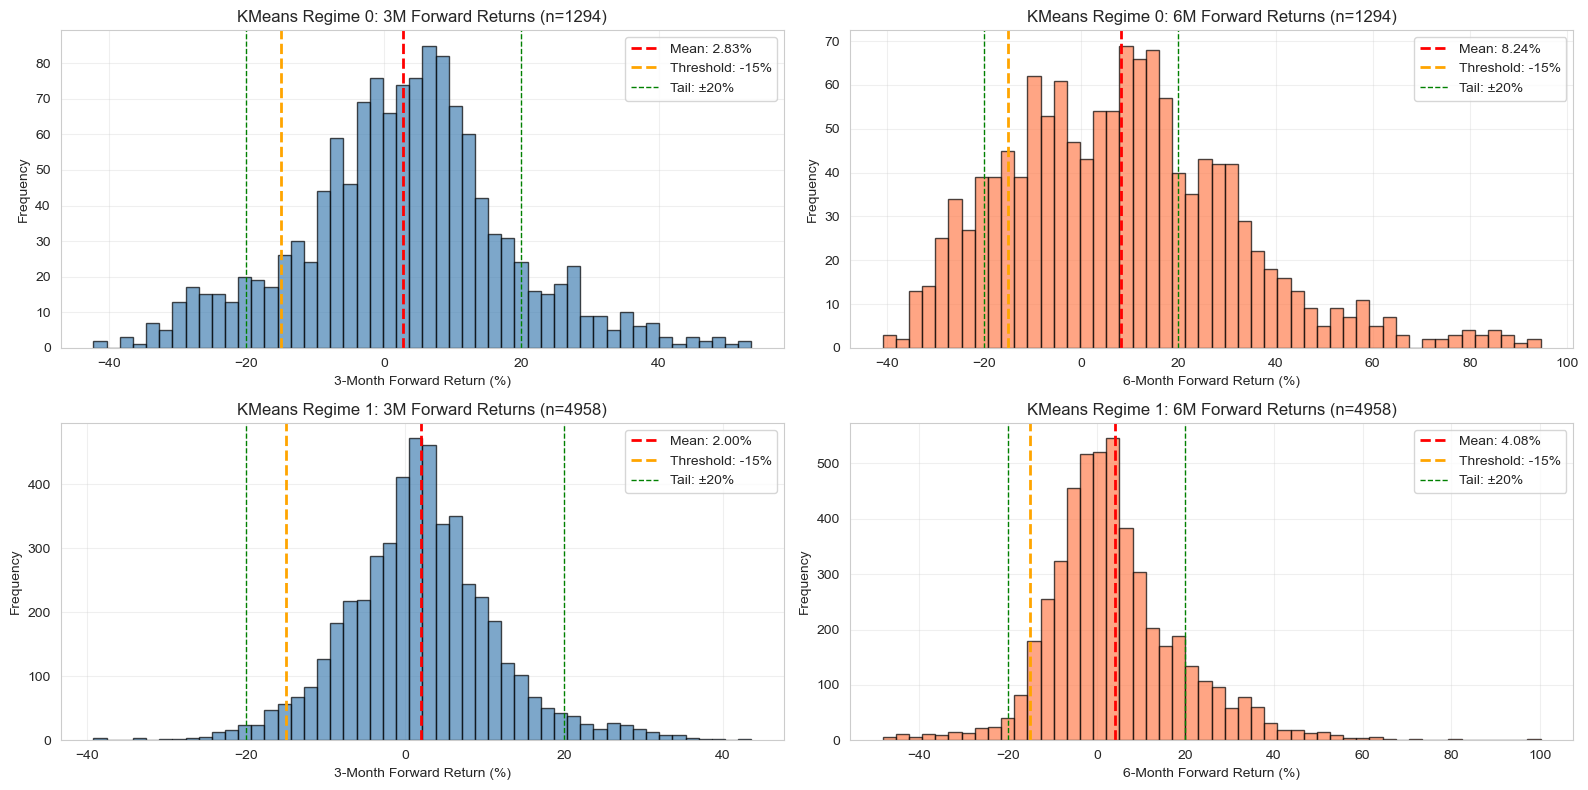

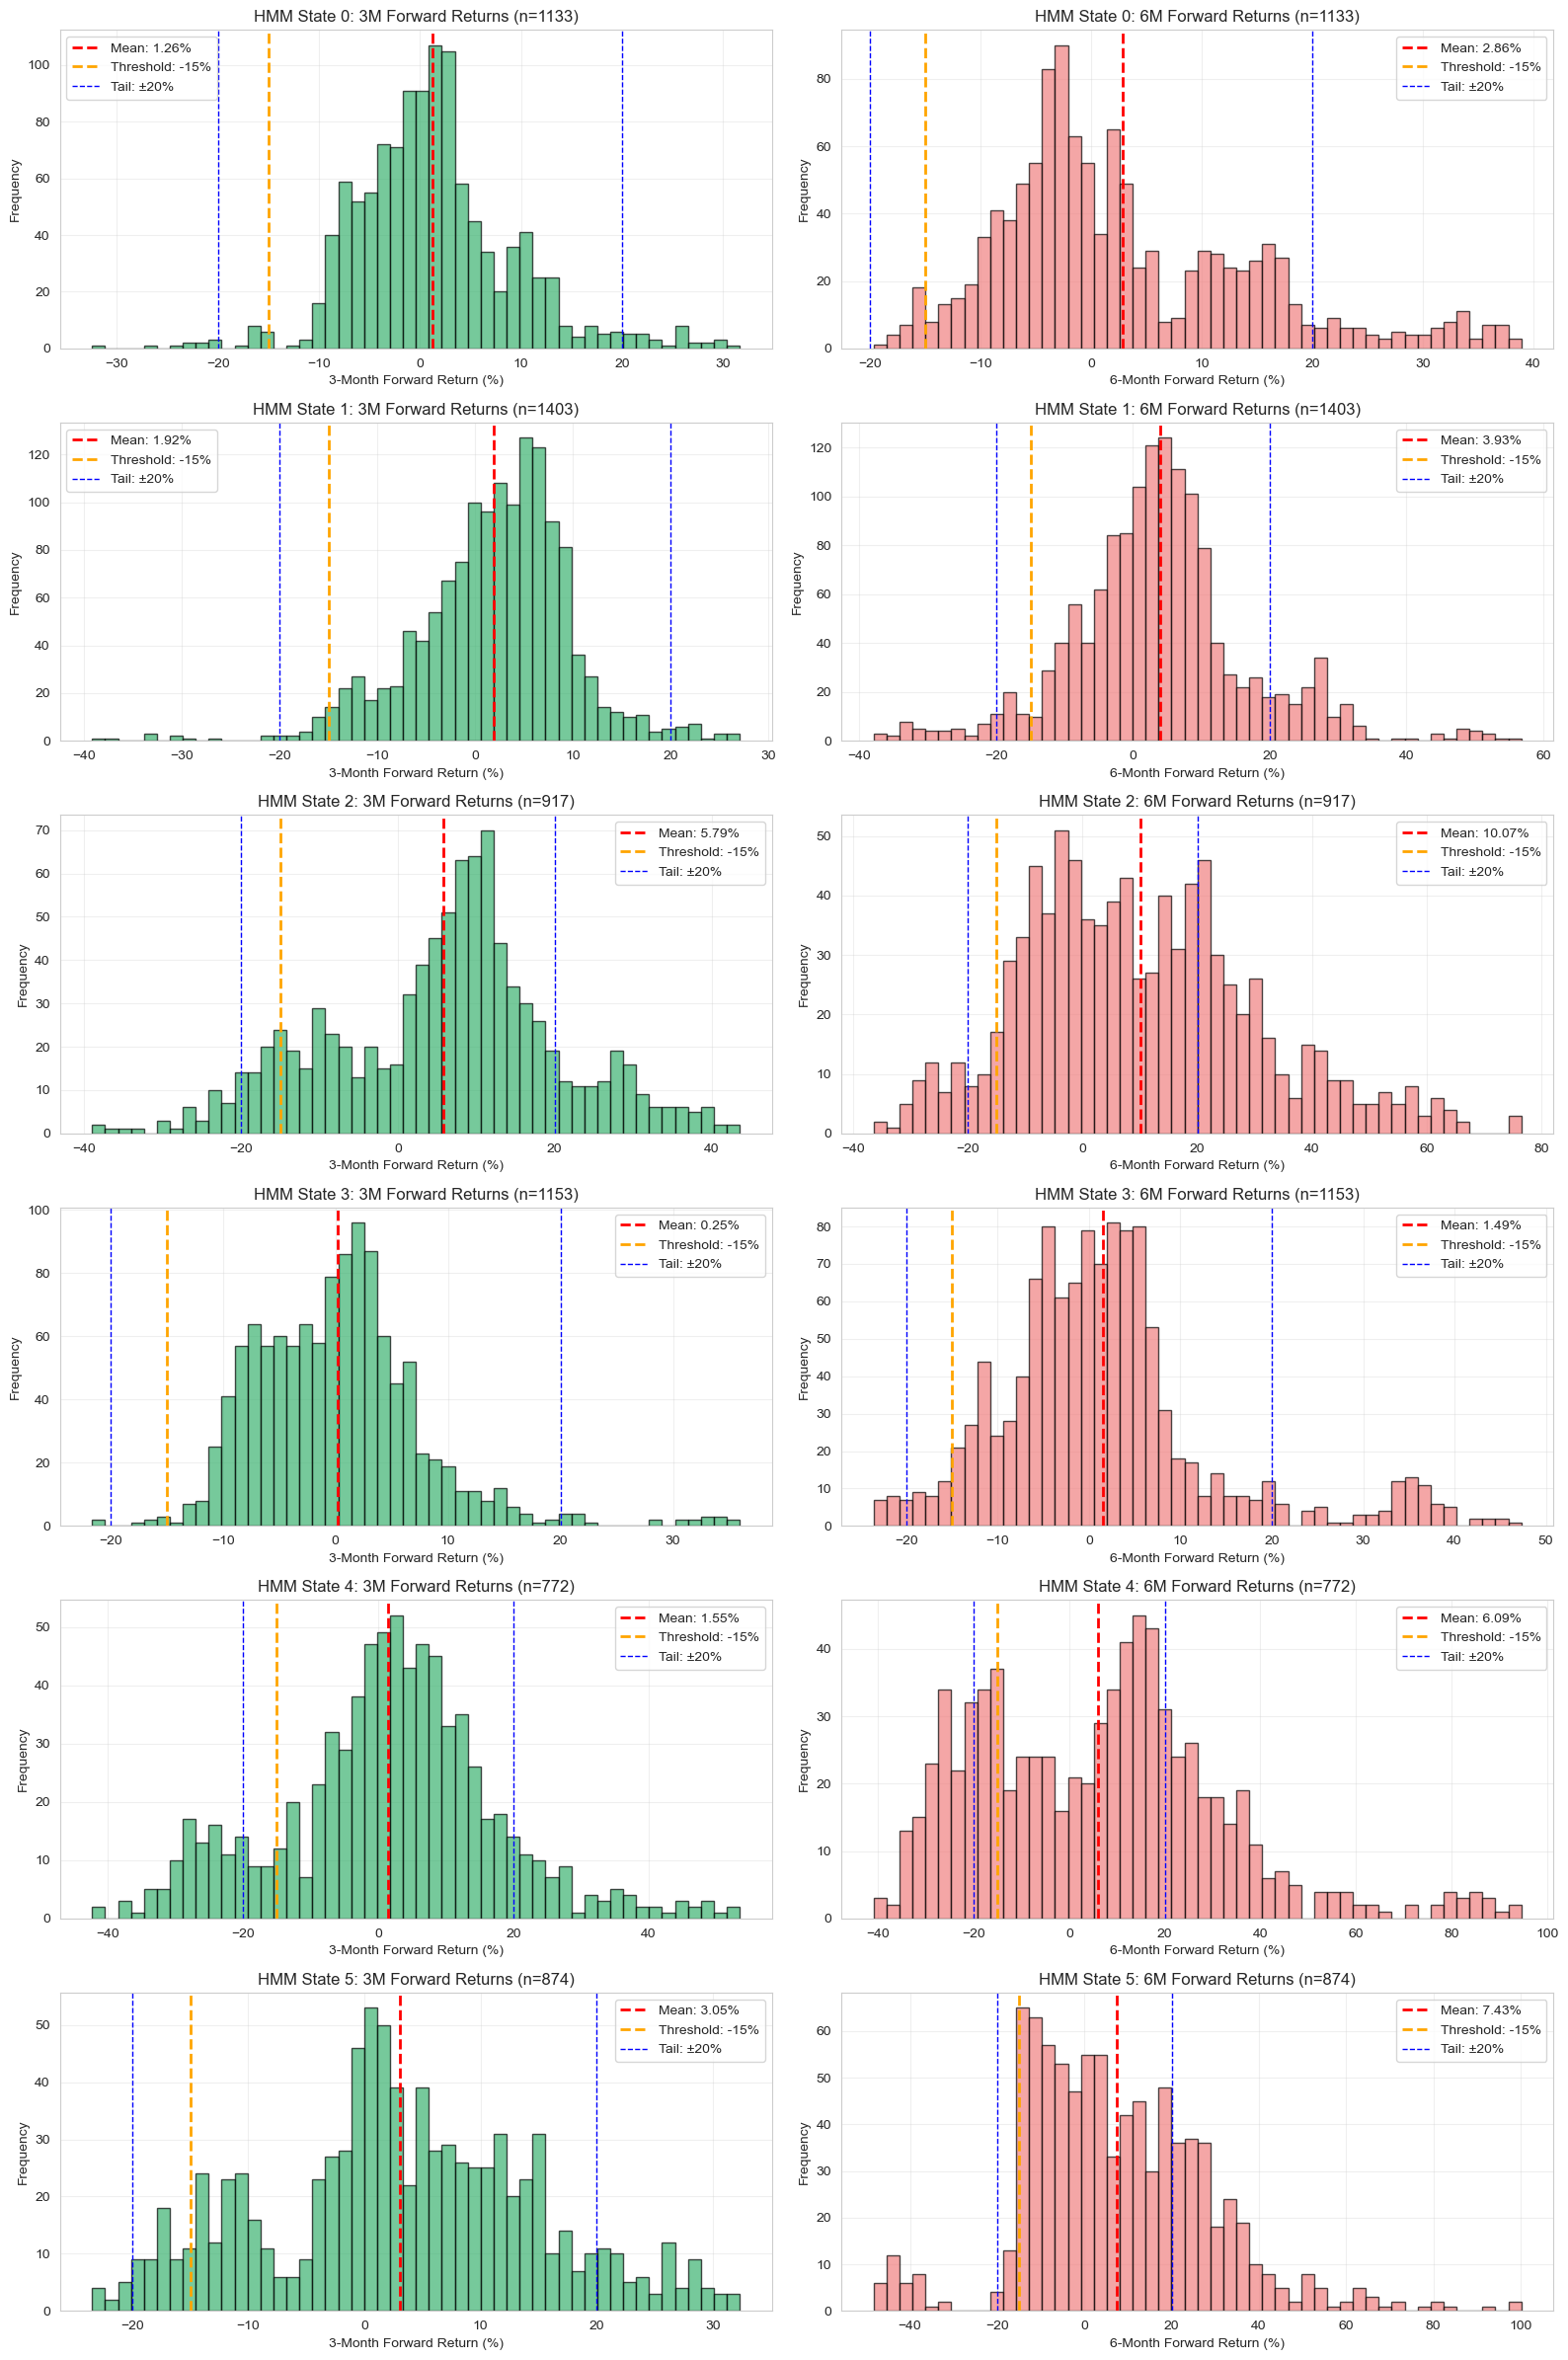

In [16]:
# ============================================================================
# SECTION 7: FORWARD RETURN DISTRIBUTION PLOTS
# ============================================================================
# Visualize 3-month and 6-month forward return distributions by regime
# Mark tail probability regions

# KMeans regime distributions
fig, axes = plt.subplots(optimal_k_kmeans, 2, figsize=(16, 4*optimal_k_kmeans))
if optimal_k_kmeans == 1:
    axes = [axes]

for idx, regime in enumerate(sorted(features_df_with_forward['regime_kmeans'].unique())):
    regime_data = features_df_with_forward[features_df_with_forward['regime_kmeans'] == regime]
    returns_3m = regime_data['63d_return'] * 100  # Convert to percentage
    returns_6m = regime_data['126d_return'] * 100
    
    # 3-Month histogram
    ax = axes[idx][0]
    ax.hist(returns_3m, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(returns_3m.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {returns_3m.mean():.2f}%")
    ax.axvline(-15, color='orange', linestyle='--', linewidth=2, label=f"Threshold: -15%")
    ax.axvline(20, color='green', linestyle='--', linewidth=1, label=f"Tail: ±20%")
    ax.axvline(-20, color='green', linestyle='--', linewidth=1)
    ax.set_xlabel('3-Month Forward Return (%)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'KMeans Regime {regime}: 3M Forward Returns (n={len(returns_3m)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6-Month histogram
    ax = axes[idx][1]
    ax.hist(returns_6m, bins=50, alpha=0.7, color='coral', edgecolor='black')
    ax.axvline(returns_6m.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {returns_6m.mean():.2f}%")
    ax.axvline(-15, color='orange', linestyle='--', linewidth=2, label=f"Threshold: -15%")
    ax.axvline(20, color='green', linestyle='--', linewidth=1, label=f"Tail: ±20%")
    ax.axvline(-20, color='green', linestyle='--', linewidth=1)
    ax.set_xlabel('6-Month Forward Return (%)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'KMeans Regime {regime}: 6M Forward Returns (n={len(returns_6m)})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# HMM state distributions
fig, axes = plt.subplots(optimal_states_hmm, 2, figsize=(16, 4*optimal_states_hmm))
if optimal_states_hmm == 1:
    axes = [axes]

for idx, state in enumerate(sorted(features_df_with_forward['regime_hmm'].unique())):
    state_data = features_df_with_forward[features_df_with_forward['regime_hmm'] == state]
    returns_3m = state_data['63d_return'] * 100
    returns_6m = state_data['126d_return'] * 100
    
    # 3-Month histogram
    ax = axes[idx][0]
    ax.hist(returns_3m, bins=50, alpha=0.7, color='mediumseagreen', edgecolor='black')
    ax.axvline(returns_3m.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {returns_3m.mean():.2f}%")
    ax.axvline(-15, color='orange', linestyle='--', linewidth=2, label=f"Threshold: -15%")
    ax.axvline(20, color='blue', linestyle='--', linewidth=1, label=f"Tail: ±20%")
    ax.axvline(-20, color='blue', linestyle='--', linewidth=1)
    ax.set_xlabel('3-Month Forward Return (%)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'HMM State {state}: 3M Forward Returns (n={len(returns_3m)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6-Month histogram
    ax = axes[idx][1]
    ax.hist(returns_6m, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    ax.axvline(returns_6m.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {returns_6m.mean():.2f}%")
    ax.axvline(-15, color='orange', linestyle='--', linewidth=2, label=f"Threshold: -15%")
    ax.axvline(20, color='blue', linestyle='--', linewidth=1, label=f"Tail: ±20%")
    ax.axvline(-20, color='blue', linestyle='--', linewidth=1)
    ax.set_xlabel('6-Month Forward Return (%)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'HMM State {state}: 6M Forward Returns (n={len(returns_6m)})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Structured Product Payoff Configuration

In [17]:
# ============================================================================
# SECTION 8: STRUCTURED PRODUCT PAYOFF CONFIGURATION
# ============================================================================
# Define payoff functions for 4 structured products
# Parameters are easily adjustable in this section

# *** PRODUCT PARAMETERS (CUSTOMIZE HERE) ***
RISK_FREE_RATE = 0.03  # 3% for cash/deposit

# ELD Parameters
ELD_CAP = 0.12  # 12% cap on upside
ELD_PARTICIPATION = 1.0  # 100% participation in gains up to cap

# KI-ELS Parameters
KI_ELS_COUPON_ANNUAL = 0.08  # 8% annual coupon
KI_ELS_BARRIER = -0.30  # -30% knock-in barrier (auto-call if breached)

print("="*80)
print("STRUCTURED PRODUCT PAYOFF FUNCTIONS")
print("="*80)
print(f"\nConfiguration Parameters:")
print(f"  Risk-Free Rate:              {RISK_FREE_RATE*100:.2f}%")
print(f"  ELD Cap:                     {ELD_CAP*100:.2f}%")
print(f"  ELD Participation:           {ELD_PARTICIPATION*100:.2f}%")
print(f"  KI-ELS Annual Coupon:        {KI_ELS_COUPON_ANNUAL*100:.2f}%")
print(f"  KI-ELS Barrier:              {KI_ELS_BARRIER*100:.2f}%")

def payoff_etf(stock_return):
    """
    ETF (Benchmark): Full market exposure
    Payoff = market return
    """
    return stock_return

def payoff_cash(stock_return, risk_free=RISK_FREE_RATE, period=0.25):
    """
    Cash/Deposit: Fixed return regardless of market
    Payoff = risk_free_rate * period
    
    Parameters:
    period: fraction of year (default 0.25 for 3 months)
    """
    return risk_free * period

def payoff_eld(stock_return, cap=ELD_CAP, participation=ELD_PARTICIPATION, principal_protect=1.0):
    """
    ELD (Equity-Linked Deposit):
    - 100% principal protection (never lose principal)
    - Participation in gains with cap
    Payoff = max(capped_return, 0) where capped_return = min(participation * return, cap)
    """
    if stock_return >= 0:
        capped_return = min(participation * stock_return, cap)
    else:
        # Principal protected: downside is 0
        capped_return = 0
    return capped_return

def payoff_kielS(stock_return, coupon=KI_ELS_COUPON_ANNUAL, barrier=KI_ELS_BARRIER, period=0.25):
    """
    KI-ELS (Knock-In Equity-Linked Securities):
    - Monthly coupon payment (8% annual = 2% per quarter)
    - Principal at risk if barrier is knocked in
    - Simplified: assume knock-in barrier is HIT if ANY point in period crosses barrier
    - If barrier knocked in: lose principal
    - If barrier NOT knocked in: receive coupon
    
    Parameters:
    coupon: annual coupon rate
    barrier: barrier level (e.g., -30% for -30% barrier)
    period: fraction of year
    
    Simplification: Assume barrier is knocked in if return goes below barrier
    (In reality, this requires checking minimum price during period, which we approximate)
    """
    coupon_payment = coupon * period
    
    # Simplified logic: if stock falls below barrier, KI happens
    if stock_return <= barrier:
        # Barrier knocked in: lose principal, get nothing
        payoff = -1.0
    else:
        # Barrier not knocked in: get coupon + principal
        payoff = coupon_payment
    
    return payoff

# Test payoff functions with example returns
test_returns = np.array([-0.30, -0.15, 0.0, 0.05, 0.12, 0.20, 0.30])

print("\n" + "="*80)
print("PAYOFF FUNCTION EXAMPLES")
print("="*80)
print(f"\n{'Return':<10} {'ETF':<10} {'Cash':<10} {'ELD':<10} {'KI-ELS':<10}")
print("-" * 50)

for ret in test_returns:
    etf_payoff = payoff_etf(ret)
    cash_payoff = payoff_cash(ret, period=0.25)  # 3-month
    eld_payoff = payoff_eld(ret)
    kielS_payoff = payoff_kielS(ret, period=0.25)
    
    print(f"{ret*100:7.1f}%   {etf_payoff*100:7.2f}%   {cash_payoff*100:7.2f}%   {eld_payoff*100:7.2f}%   {kielS_payoff*100:7.2f}%")

print("\nNote: Cash/KI-ELS payoffs shown are for 3-month period.")
print("KI-ELS shows principal loss (-100%) if barrier is knocked in.")

STRUCTURED PRODUCT PAYOFF FUNCTIONS

Configuration Parameters:
  Risk-Free Rate:              3.00%
  ELD Cap:                     12.00%
  ELD Participation:           100.00%
  KI-ELS Annual Coupon:        8.00%
  KI-ELS Barrier:              -30.00%

PAYOFF FUNCTION EXAMPLES

Return     ETF        Cash       ELD        KI-ELS    
--------------------------------------------------
  -30.0%    -30.00%      0.75%      0.00%   -100.00%
  -15.0%    -15.00%      0.75%      0.00%      2.00%
    0.0%      0.00%      0.75%      0.00%      2.00%
    5.0%      5.00%      0.75%      5.00%      2.00%
   12.0%     12.00%      0.75%     12.00%      2.00%
   20.0%     20.00%      0.75%     12.00%      2.00%
   30.0%     30.00%      0.75%     12.00%      2.00%

Note: Cash/KI-ELS payoffs shown are for 3-month period.
KI-ELS shows principal loss (-100%) if barrier is knocked in.


## 9. Expected Return Calculation by Regime

In [18]:
# ============================================================================
# SECTION 9: EXPECTED RETURN CALCULATION
# ============================================================================
# Calculate expected returns for each product under each regime
# Expected Return = Σ (scenario probability × payoff)

def calculate_expected_returns(regime_returns, period=0.25):
    """
    Calculate expected returns for all 4 products given regime return distribution.
    
    Parameters:
    -----------
    regime_returns : pd.Series
        Historical returns that occurred in this regime
    period : float
        Time period for forward return (as fraction of year)
    
    Returns:
    --------
    dict
        Expected returns for each product
    """
    # Calculate payoffs for each historical return
    payoffs_etf = np.array([payoff_etf(r) for r in regime_returns])
    payoffs_cash = np.array([payoff_cash(r, period=period) for r in regime_returns])
    payoffs_eld = np.array([payoff_eld(r) for r in regime_returns])
    payoffs_kielS = np.array([payoff_kielS(r, period=period) for r in regime_returns])
    
    # Expected return = average payoff (assuming uniform probability)
    expected_returns = {
        'ETF': payoffs_etf.mean(),
        'Cash': payoffs_cash.mean(),
        'ELD': payoffs_eld.mean(),
        'KI-ELS': payoffs_kielS.mean(),
    }
    
    return expected_returns, payoffs_etf, payoffs_cash, payoffs_eld, payoffs_kielS

# Calculate expected returns for KMeans regimes
print("="*80)
print("EXPECTED RETURNS BY KMEANS REGIME (3-Month Horizon)")
print("="*80)

kmeans_expected = {}
for regime in sorted(features_df_with_forward['regime_kmeans'].unique()):
    regime_data = features_df_with_forward[features_df_with_forward['regime_kmeans'] == regime]
    returns = regime_data['63d_return'].values  # 3-month forward returns
    
    expected, payoffs_etf, payoffs_cash, payoffs_eld, payoffs_kielS = calculate_expected_returns(returns, period=0.25)
    kmeans_expected[regime] = expected
    
    print(f"\nKMeans Regime {regime}:")
    print(f"  ETF:       {expected['ETF']*100:7.2f}%")
    print(f"  Cash:      {expected['Cash']*100:7.2f}%")
    print(f"  ELD:       {expected['ELD']*100:7.2f}%")
    print(f"  KI-ELS:    {expected['KI-ELS']*100:7.2f}%")
    
    # Calculate payoff statistics
    print(f"\n  ELD Payoff Statistics:")
    print(f"    Min:        {payoffs_eld.min()*100:7.2f}%")
    print(f"    Max:        {payoffs_eld.max()*100:7.2f}%")
    print(f"    Std Dev:    {payoffs_eld.std()*100:7.2f}%")
    print(f"  KI-ELS Payoff Statistics:")
    print(f"    Min:        {payoffs_kielS.min()*100:7.2f}%")
    print(f"    Max:        {payoffs_kielS.max()*100:7.2f}%")
    print(f"    Std Dev:    {payoffs_kielS.std()*100:7.2f}%")

print("\n" + "="*80)
print("EXPECTED RETURNS BY HMM STATE (3-Month Horizon)")
print("="*80)

hmm_expected = {}
for state in sorted(features_df_with_forward['regime_hmm'].unique()):
    state_data = features_df_with_forward[features_df_with_forward['regime_hmm'] == state]
    returns = state_data['63d_return'].values
    
    expected, payoffs_etf, payoffs_cash, payoffs_eld, payoffs_kielS = calculate_expected_returns(returns, period=0.25)
    hmm_expected[state] = expected
    
    print(f"\nHMM State {state}:")
    print(f"  ETF:       {expected['ETF']*100:7.2f}%")
    print(f"  Cash:      {expected['Cash']*100:7.2f}%")
    print(f"  ELD:       {expected['ELD']*100:7.2f}%")
    print(f"  KI-ELS:    {expected['KI-ELS']*100:7.2f}%")
    
    print(f"\n  ELD Payoff Statistics:")
    print(f"    Min:        {payoffs_eld.min()*100:7.2f}%")
    print(f"    Max:        {payoffs_eld.max()*100:7.2f}%")
    print(f"    Std Dev:    {payoffs_eld.std()*100:7.2f}%")
    print(f"  KI-ELS Payoff Statistics:")
    print(f"    Min:        {payoffs_kielS.min()*100:7.2f}%")
    print(f"    Max:        {payoffs_kielS.max()*100:7.2f}%")
    print(f"    Std Dev:    {payoffs_kielS.std()*100:7.2f}%")

EXPECTED RETURNS BY KMEANS REGIME (3-Month Horizon)

KMeans Regime 0:
  ETF:          2.83%
  Cash:         0.75%
  ELD:          4.96%
  KI-ELS:       0.11%

  ELD Payoff Statistics:
    Min:           0.00%
    Max:          12.00%
    Std Dev:       5.09%
  KI-ELS Payoff Statistics:
    Min:        -100.00%
    Max:           2.00%
    Std Dev:      13.76%

KMeans Regime 1:
  ETF:          2.00%
  Cash:         0.75%
  ELD:          3.82%
  KI-ELS:       1.77%

  ELD Payoff Statistics:
    Min:           0.00%
    Max:          12.00%
    Std Dev:       4.42%
  KI-ELS Payoff Statistics:
    Min:        -100.00%
    Max:           2.00%
    Std Dev:       4.80%

EXPECTED RETURNS BY HMM STATE (3-Month Horizon)

HMM State 0:
  ETF:          1.26%
  Cash:         0.75%
  ELD:          3.03%
  KI-ELS:       1.91%

  ELD Payoff Statistics:
    Min:           0.00%
    Max:          12.00%
    Std Dev:       4.10%
  KI-ELS Payoff Statistics:
    Min:        -100.00%
    Max:           2.00

## 10. Expected Return Comparison Visualization

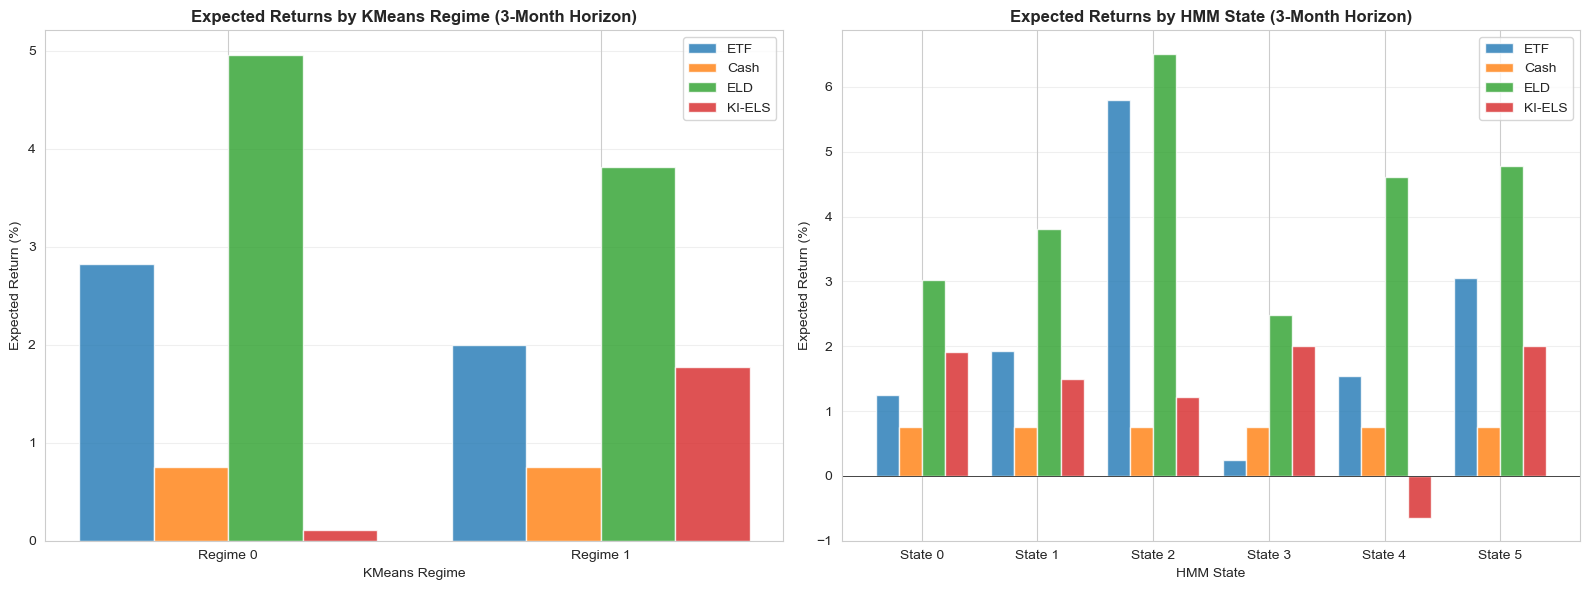


EXPECTED RETURN SUMMARY TABLE

KMeans Regimes:
           ETF  Cash   ELD  KI-ELS
Regime 0  2.83  0.75  4.96    0.11
Regime 1  2.00  0.75  3.82    1.77

HMM States:
          ETF  Cash   ELD  KI-ELS
State 0  1.26  0.75  3.03    1.91
State 1  1.92  0.75  3.80    1.49
State 2  5.79  0.75  6.51    1.22
State 3  0.25  0.75  2.48    2.00
State 4  1.55  0.75  4.61   -0.64
State 5  3.05  0.75  4.78    2.00


In [19]:
# ============================================================================
# SECTION 10: EXPECTED RETURN VISUALIZATION
# ============================================================================

# Visualize expected returns comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans expected returns
regimes = sorted(kmeans_expected.keys())
products = ['ETF', 'Cash', 'ELD', 'KI-ELS']
expected_matrix_kmeans = np.array([[kmeans_expected[r][p]*100 for p in products] for r in regimes])

ax = axes[0]
x = np.arange(len(regimes))
width = 0.2
for i, product in enumerate(products):
    ax.bar(x + i*width, expected_matrix_kmeans[:, i], width, label=product, alpha=0.8)
ax.set_xlabel('KMeans Regime')
ax.set_ylabel('Expected Return (%)')
ax.set_title('Expected Returns by KMeans Regime (3-Month Horizon)', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Regime {r}' for r in regimes])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)

# HMM expected returns
states = sorted(hmm_expected.keys())
expected_matrix_hmm = np.array([[hmm_expected[s][p]*100 for p in products] for s in states])

ax = axes[1]
x = np.arange(len(states))
width = 0.2
for i, product in enumerate(products):
    ax.bar(x + i*width, expected_matrix_hmm[:, i], width, label=product, alpha=0.8)
ax.set_xlabel('HMM State')
ax.set_ylabel('Expected Return (%)')
ax.set_title('Expected Returns by HMM State (3-Month Horizon)', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'State {s}' for s in states])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*80)
print("EXPECTED RETURN SUMMARY TABLE")
print("="*80)

print("\nKMeans Regimes:")
df_kmeans = pd.DataFrame(expected_matrix_kmeans, 
                         index=[f'Regime {r}' for r in regimes],
                         columns=products)
df_kmeans = df_kmeans.round(2)
print(df_kmeans.to_string())

print("\nHMM States:")
df_hmm = pd.DataFrame(expected_matrix_hmm,
                      index=[f'State {s}' for s in states],
                      columns=products)
df_hmm = df_hmm.round(2)
print(df_hmm.to_string())

## 11. Current Regime Analysis & ELD Rationality Assessment

In [20]:
# ============================================================================
# SECTION 11: CURRENT REGIME ANALYSIS
# ============================================================================
# Determine current regime and evaluate ELD rationality

current_kmeans_regime = features_df['regime_kmeans'].iloc[-1]
current_hmm_state = features_df['regime_hmm'].iloc[-1]
current_date = features_df.index[-1].date()

print("="*80)
print("CURRENT MARKET REGIME STATUS")
print("="*80)
print(f"\nAnalysis Date: {current_date}")
print(f"Current KMeans Regime: {current_kmeans_regime}")
print(f"Current HMM State: {current_hmm_state}")

# Get current regime statistics
current_regime_data = features_df[features_df['regime_kmeans'] == current_kmeans_regime].tail(60)
print(f"\nRegime Statistics (Last 60 days in current regime):")
print(f"  Avg Daily Return:    {current_regime_data['daily_return'].mean()*100:7.3f}%")
print(f"  Volatility:          {current_regime_data['volatility_20d'].mean()*100:7.3f}%")
print(f"  Current Drawdown:    {features_df['drawdown'].iloc[-1]*100:7.3f}%")
print(f"  1M Momentum:         {current_regime_data['momentum_1m'].mean()*100:7.3f}%")
print(f"  3M Momentum:         {current_regime_data['momentum_3m'].mean()*100:7.3f}%")

# Get expected returns for current regime
kmeans_current_expected = kmeans_expected[current_kmeans_regime]
hmm_current_expected = hmm_expected[current_hmm_state]

print(f"\n" + "="*80)
print("EXPECTED RETURNS - CURRENT REGIME (3-Month Horizon)")
print("="*80)

print(f"\nKMeans Regime {current_kmeans_regime}:")
print(f"  ETF:       {kmeans_current_expected['ETF']*100:7.2f}%")
print(f"  Cash:      {kmeans_current_expected['Cash']*100:7.2f}%")
print(f"  ELD:       {kmeans_current_expected['ELD']*100:7.2f}%")
print(f"  KI-ELS:    {kmeans_current_expected['KI-ELS']*100:7.2f}%")

print(f"\nHMM State {current_hmm_state}:")
print(f"  ETF:       {hmm_current_expected['ETF']*100:7.2f}%")
print(f"  Cash:      {hmm_current_expected['Cash']*100:7.2f}%")
print(f"  ELD:       {hmm_current_expected['ELD']*100:7.2f}%")
print(f"  KI-ELS:    {hmm_current_expected['KI-ELS']*100:7.2f}%")

# Get tail probabilities for current regime
current_regime_full = features_df_with_forward[features_df_with_forward['regime_kmeans'] == current_kmeans_regime]
returns_3m_current = current_regime_full['63d_return']
returns_6m_current = current_regime_full['126d_return']

prob_loss_15_3m = (returns_3m_current < -0.15).sum() / len(returns_3m_current)
prob_tail_20_3m = (abs(returns_3m_current) > 0.20).sum() / len(returns_3m_current)
prob_loss_15_6m = (returns_6m_current < -0.15).sum() / len(returns_6m_current)
prob_tail_20_6m = (abs(returns_6m_current) > 0.20).sum() / len(returns_6m_current)

print(f"\n" + "="*80)
print("TAIL PROBABILITIES - CURRENT REGIME")
print("="*80)
print(f"\n3-Month Forward Returns:")
print(f"  P(Return < -15%):    {prob_loss_15_3m*100:7.2f}%")
print(f"  P(|Return| > 20%):   {prob_tail_20_3m*100:7.2f}%")
print(f"  Mean:                {returns_3m_current.mean()*100:7.2f}%")
print(f"  Median:              {returns_3m_current.median()*100:7.2f}%")
print(f"  Std Dev:             {returns_3m_current.std()*100:7.2f}%")

print(f"\n6-Month Forward Returns:")
print(f"  P(Return < -15%):    {prob_loss_15_6m*100:7.2f}%")
print(f"  P(|Return| > 20%):   {prob_tail_20_6m*100:7.2f}%")
print(f"  Mean:                {returns_6m_current.mean()*100:7.2f}%")
print(f"  Median:              {returns_6m_current.median()*100:7.2f}%")
print(f"  Std Dev:             {returns_6m_current.std()*100:7.2f}%")

CURRENT MARKET REGIME STATUS

Analysis Date: 2026-02-27
Current KMeans Regime: 1
Current HMM State: 2

Regime Statistics (Last 60 days in current regime):
  Avg Daily Return:      0.767%
  Volatility:           27.763%
  Current Drawdown:     -1.001%
  1M Momentum:          11.829%
  3M Momentum:          29.712%

EXPECTED RETURNS - CURRENT REGIME (3-Month Horizon)

KMeans Regime 1:
  ETF:          2.00%
  Cash:         0.75%
  ELD:          3.82%
  KI-ELS:       1.77%

HMM State 2:
  ETF:          5.79%
  Cash:         0.75%
  ELD:          6.51%
  KI-ELS:       1.22%

TAIL PROBABILITIES - CURRENT REGIME

3-Month Forward Returns:
  P(Return < -15%):       3.57%
  P(|Return| > 20%):      5.59%
  Mean:                   2.00%
  Median:                 1.84%
  Std Dev:                9.57%

6-Month Forward Returns:
  P(Return < -15%):       5.75%
  P(|Return| > 20%):     16.24%
  Mean:                   4.08%
  Median:                 2.09%
  Std Dev:               15.23%


## 12. Conclusion: Is ELD Rational?

In [21]:
# ============================================================================
# SECTION 12: FINAL CONCLUSION & RECOMMENDATION
# ============================================================================
# Evaluate whether ELD is rational under current regime
# Case 1: Defensive Regime (high drawdown, negative returns)
# Case 2: Bull Regime (strong momentum, positive returns)
# Case 3: Neutral Regime (sideways, moderate volatility)

print("\n" + "="*80)
print("FINAL ANALYSIS: IS ELD A RATIONAL CHOICE?")
print("="*80)

# Regime classification
avg_drawdown = current_regime_data['drawdown'].mean()
avg_momentum_3m = current_regime_data['momentum_3m'].mean()
avg_volatility = current_regime_data['volatility_20d'].mean()
avg_return = current_regime_data['daily_return'].mean()

print(f"\nCURRENT REGIME CHARACTERISTICS:")
print(f"  Average Daily Return:    {avg_return*100:7.3f}%")
print(f"  Average Volatility:      {avg_volatility*100:7.3f}%")
print(f"  Average Drawdown:        {avg_drawdown*100:7.3f}%")
print(f"  3-Month Momentum:        {avg_momentum_3m*100:7.3f}%")

# Classify regime
if avg_drawdown < -0.15 or avg_momentum_3m < -0.05:  # Defensive
    regime_type = "CASE 1: DEFENSIVE REGIME"
    regime_description = "High drawdown, negative momentum - market stress/decline"
elif avg_momentum_3m > 0.10 and avg_drawdown > -0.10:  # Bull
    regime_type = "CASE 2: BULL REGIME"
    regime_description = "Strong momentum, minimal drawdown - growth environment"
else:  # Neutral
    regime_type = "CASE 3: NEUTRAL REGIME"
    regime_description = "Moderate characteristics - sideways/consolidating market"

print(f"\nREGIME CLASSIFICATION: {regime_type}")
print(f"Description: {regime_description}")

print(f"\n" + "="*80)
print(f"ELD vs. COMPETING PRODUCTS")
print("="*80)

print(f"\nExpected Return (3-Month):")
print(f"  ELD:    {kmeans_current_expected['ELD']*100:7.2f}%  (Principal protected, capped upside)")
print(f"  ETF:    {kmeans_current_expected['ETF']*100:7.2f}%  (Full market exposure, full downside risk)")
print(f"  Cash:   {kmeans_current_expected['Cash']*100:7.2f}%  (Risk-free alternative)")
print(f"  KI-ELS: {kmeans_current_expected['KI-ELS']*100:7.2f}%  (High coupon, barrier risk)")

eld_premium_vs_cash = kmeans_current_expected['ELD'] - kmeans_current_expected['Cash']
eld_shortfall_vs_etf = kmeans_current_expected['ETF'] - kmeans_current_expected['ELD']

print(f"\nKEY METRICS:")
print(f"  ELD Premium over Cash:     {eld_premium_vs_cash*100:7.2f}%  (benefit for principal protection)")
print(f"  ELD Shortfall vs ETF:      {eld_shortfall_vs_etf*100:7.2f}%  (cost of cap)")
print(f"  Default Probability (KOSPI bankruptcy): <0.01%  (implicit ELD assumption)")
print(f"  Tail Risk (P(Return<-15%)):  {prob_loss_15_3m*100:7.2f}%")
print(f"  Extreme Risk (P(|Return|>20%)): {prob_tail_20_3m*100:7.2f}%")

print(f"\n" + "="*80)
print(f"RECOMMENDATION")
print("="*80)

if regime_type.startswith("CASE 1"):
    print(f"\n✓ ELD IS RATIONAL in {regime_type}")
    print(f"\nRationale:")
    print(f"  1. Market downside risk is elevated ({prob_loss_15_3m*100:.1f}% probability of -15%+ loss)")
    print(f"  2. Principal protection becomes valuable insurance")
    print(f"  3. ELD expected return ({kmeans_current_expected['ELD']*100:.2f}%) still exceeds cash ({kmeans_current_expected['Cash']*100:.2f}%)")
    print(f"  4. Cap ({ELD_CAP*100:.0f}%) provides limited but positive upside")
    print(f"\nTarget Investors:")
    print(f"  - Risk-averse portfolios seeking capital preservation")
    print(f"  - Near-retirement individuals wanting equity exposure with protection")
    print(f"  - Investors expecting sideways or negative market conditions")
    
elif regime_type.startswith("CASE 2"):
    print(f"\n✗ ELD IS NOT RATIONAL in {regime_type}")
    print(f"\nRationale:")
    print(f"  1. Bull market favors uncapped returns (ETF: {kmeans_current_expected['ETF']*100:.2f}% vs ELD: {kmeans_current_expected['ELD']*100:.2f}%)")
    print(f"  2. Principal protection is unnecessary (low tail risk: {prob_loss_15_3m*100:.1f}%)")
    print(f"  3. ELD cap ({ELD_CAP*100:.0f}%) limits gains significantly")
    print(f"  4. Alternative: Direct ETF exposure captures full market upside")
    print(f"\nBetter Alternative:")
    print(f"  - Direct KOSPI ETF investment for capital appreciation")
    print(f"  - Leverage if risk tolerance allows")
    
else:  # NEUTRAL
    print(f"\n≈ ELD ACCEPTABILITY DEPENDS ON PREFERENCES in {regime_type}")
    print(f"\nRationale:")
    print(f"  1. Moderate market conditions: tail risks manageable ({prob_loss_15_3m*100:.1f}%)")
    print(f"  2. Principal protection less critical but still valuable")
    print(f"  3. ELD expected return ({kmeans_current_expected['ELD']*100:.2f}%) is compromise between")
    print(f"     - Cash return ({kmeans_current_expected['Cash']*100:.2f}%): safety but low upside")
    print(f"     - ETF return ({kmeans_current_expected['ETF']*100:.2f}%): full upside but full downside")
    print(f"\nSuitable For:")
    print(f"  - Moderate risk investors seeking balance")
    print(f"  - Those valuing principal protection over maximum returns")
    print(f"  - Portfolio diversification in uncertain market environment")

print(f"\n" + "="*80)
print(f"FOR BANKS ISSUING ELD")
print("="*80)
print(f"\nIssuance Profitability: {'HIGH' if regime_type.startswith('CASE 1') else ('LOW' if regime_type.startswith('CASE 2') else 'MODERATE')}")
if regime_type.startswith("CASE 1"):
    print(f"\nIn defensive regime, retail investors heavily demand principal protection.")
    print(f"ELD sales volume likely HIGH - good opportunity for issuance.")
    print(f"Suggested bank hedge: Short KOSPI equity or buy put options")
elif regime_type.startswith("CASE 2"):
    print(f"\nIn bull regime, retail demand for ELD drops significantly.")
    print(f"Investors prefer direct ETF exposure. Sales volume likely LOW.")
    print(f"Bank should not issue ELD; better to offer leveraged products or equity indices.")
else:
    print(f"\nIn neutral regime, ELD has moderate appeal.")
    print(f"Target conservative/elderly demographics. Expect moderate sales volume.")
    print(f"Bank hedging: Balanced approach with some upside cap participation.")

print(f"\n" + "="*80)
print(f"SENSITIVITY ANALYSIS: IMPACT OF PARAMETER CHANGES")
print("="*80)

print(f"\nCurrent ELD Parameters:")
print(f"  Cap: {ELD_CAP*100:.0f}% | Participation: {ELD_PARTICIPATION*100:.0f}%")
print(f"  → Expected Return: {kmeans_current_expected['ELD']*100:.2f}%")

print(f"\nIf Cap increases to {ELD_CAP*100 + 3:.0f}%:")
eld_higher_cap = {
    'ETF': kmeans_current_expected['ETF'],
    'Cash': kmeans_current_expected['Cash'],
}
for regime in sorted(features_df_with_forward['regime_kmeans'].unique()):
    if regime == current_kmeans_regime:
        regime_data = features_df_with_forward[features_df_with_forward['regime_kmeans'] == regime]
        returns = regime_data['63d_return'].values
        higher_cap_eld = np.array([payoff_eld(r, cap=ELD_CAP+0.03) for r in returns])
        print(f"  → Expected Return: {higher_cap_eld.mean()*100:.2f}% (vs {kmeans_current_expected['ELD']*100:.2f}%)")

print(f"\nIf Participation decreases to {ELD_PARTICIPATION*100 - 10:.0f}%:")
for regime in sorted(features_df_with_forward['regime_kmeans'].unique()):
    if regime == current_kmeans_regime:
        regime_data = features_df_with_forward[features_df_with_forward['regime_kmeans'] == regime]
        returns = regime_data['63d_return'].values
        lower_part_eld = np.array([payoff_eld(r, participation=ELD_PARTICIPATION-0.1) for r in returns])
        print(f"  → Expected Return: {lower_part_eld.mean()*100:.2f}% (vs {kmeans_current_expected['ELD']*100:.2f}%)")

print(f"\n" + "="*80)
print(f"ANALYSIS COMPLETED AT {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


FINAL ANALYSIS: IS ELD A RATIONAL CHOICE?

CURRENT REGIME CHARACTERISTICS:
  Average Daily Return:      0.767%
  Average Volatility:       27.763%
  Average Drawdown:         -1.556%
  3-Month Momentum:         29.712%

REGIME CLASSIFICATION: CASE 2: BULL REGIME
Description: Strong momentum, minimal drawdown - growth environment

ELD vs. COMPETING PRODUCTS

Expected Return (3-Month):
  ELD:       3.82%  (Principal protected, capped upside)
  ETF:       2.00%  (Full market exposure, full downside risk)
  Cash:      0.75%  (Risk-free alternative)
  KI-ELS:    1.77%  (High coupon, barrier risk)

KEY METRICS:
  ELD Premium over Cash:        3.07%  (benefit for principal protection)
  ELD Shortfall vs ETF:        -1.82%  (cost of cap)
  Default Probability (KOSPI bankruptcy): <0.01%  (implicit ELD assumption)
  Tail Risk (P(Return<-15%)):     3.57%
  Extreme Risk (P(|Return|>20%)):    5.59%

RECOMMENDATION

✗ ELD IS NOT RATIONAL in CASE 2: BULL REGIME

Rationale:
  1. Bull market favors un

## 13. Run This Cell Last - Summary Dashboard

TypeError: unsupported format string passed to Series.__format__

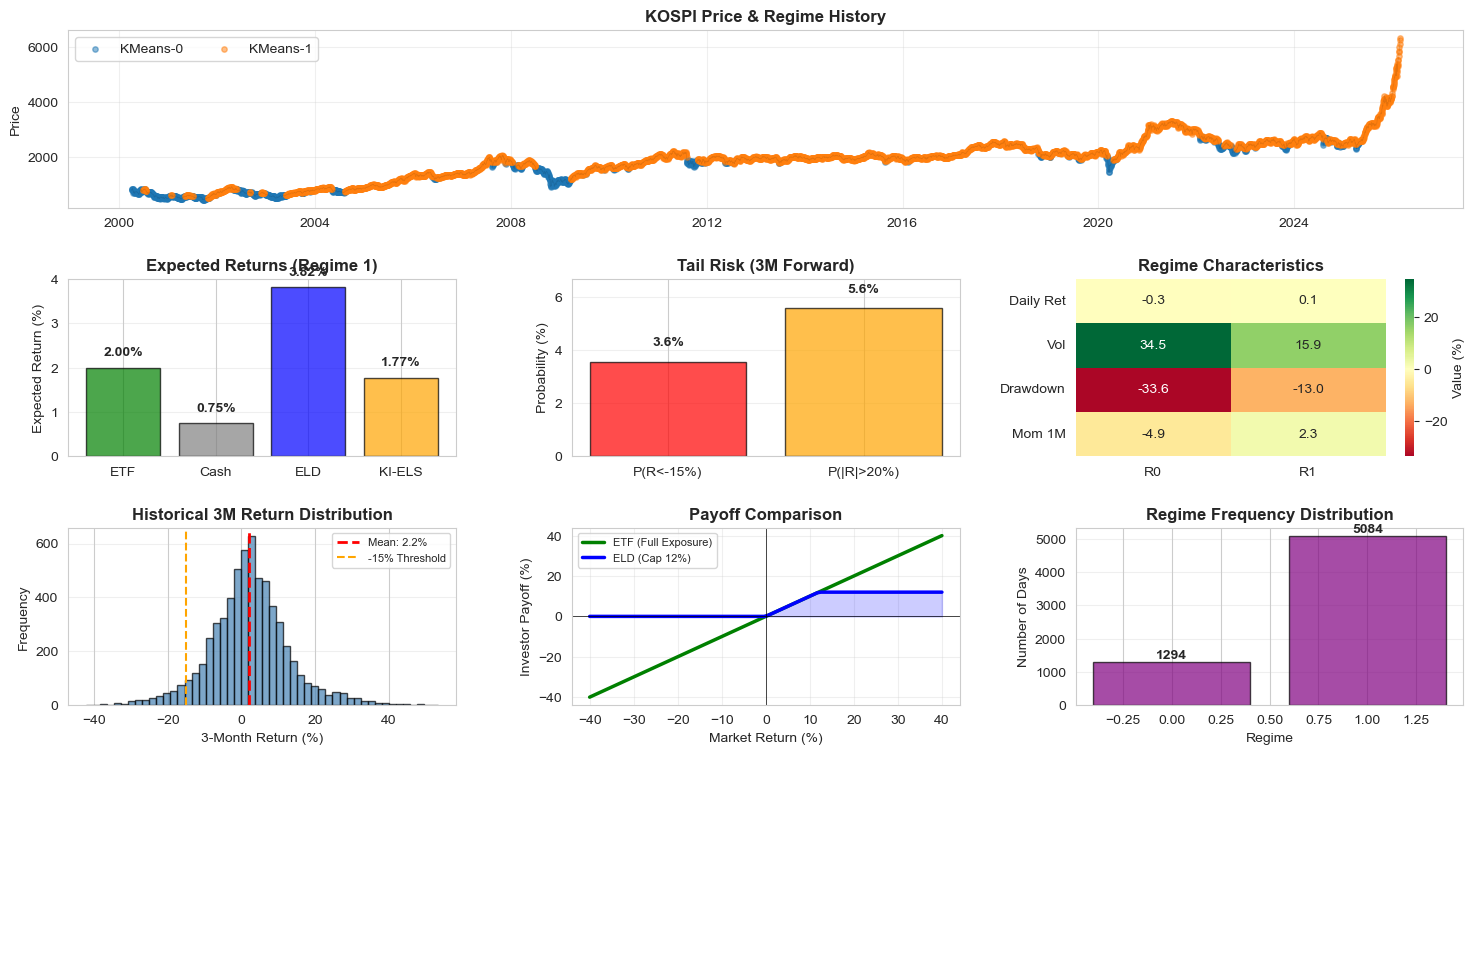

In [22]:
# ============================================================================
# SECTION 13: SUMMARY DASHBOARD (RUN THIS CELL LAST)
# ============================================================================
# Create comprehensive summary visualization

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# 1. Price and Regimes (Top, spanning 3 columns)
ax1 = fig.add_subplot(gs[0, :])
for regime in sorted(features_df['regime_kmeans'].unique()):
    mask = features_df['regime_kmeans'] == regime
    ax1.scatter(features_df.index[mask], price_aligned.loc[mask, 'price'], 
               label=f'KMeans-{regime}', alpha=0.5, s=15)
ax1.plot(features_df.index, price_aligned['price'], 'k-', alpha=0.1, linewidth=0.5)
ax1.set_title('KOSPI Price & Regime History', fontweight='bold', fontsize=12)
ax1.set_ylabel('Price')
ax1.legend(loc='upper left', ncol=len(features_df['regime_kmeans'].unique()))
ax1.grid(True, alpha=0.3)

# 2. Current Expected Returns (Bar chart)
ax2 = fig.add_subplot(gs[1, 0])
products_list = ['ETF', 'Cash', 'ELD', 'KI-ELS']
returns_list = [kmeans_current_expected[p]*100 for p in products_list]
colors = ['green', 'gray', 'blue', 'orange']
bars = ax2.bar(products_list, returns_list, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Expected Return (%)')
ax2.set_title(f'Expected Returns (Regime {current_kmeans_regime})', fontweight='bold')
ax2.axhline(0, color='k', linewidth=0.5)
for i, (bar, val) in enumerate(zip(bars, returns_list)):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.2 if val > 0 else val - 0.5, 
            f'{val:.2f}%', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Tail Risk Metrics
ax3 = fig.add_subplot(gs[1, 1])
risk_metrics = ['P(R<-15%)', 'P(|R|>20%)']
metric_values = [prob_loss_15_3m*100, prob_tail_20_3m*100]
ax3.bar(risk_metrics, metric_values, color=['red', 'orange'], alpha=0.7, edgecolor='black')
ax3.set_ylabel('Probability (%)')
ax3.set_title('Tail Risk (3M Forward)', fontweight='bold')
for i, (metric, val) in enumerate(zip(risk_metrics, metric_values)):
    ax3.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax3.set_ylim(0, max(metric_values)*1.2)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Regime Statistics Heatmap
ax4 = fig.add_subplot(gs[1, 2])
stats_for_heatmap = []
regime_labels = []
for regime in sorted(features_df['regime_kmeans'].unique()):
    regime_data = features_df[features_df['regime_kmeans'] == regime]
    stats = [
        regime_data['daily_return'].mean()*100,
        regime_data['volatility_20d'].mean()*100,
        regime_data['drawdown'].mean()*100,
        regime_data['momentum_1m'].mean()*100
    ]
    stats_for_heatmap.append(stats)
    regime_labels.append(f'R{regime}')

stats_array = np.array(stats_for_heatmap).T
feature_names = ['Daily Ret', 'Vol', 'Drawdown', 'Mom 1M']
sns.heatmap(stats_array, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
           xticklabels=regime_labels, yticklabels=feature_names, ax=ax4,
           cbar_kws={'label': 'Value (%)'})
ax4.set_title('Regime Characteristics', fontweight='bold')

# 5. Forward Return Distribution (3M)
ax5 = fig.add_subplot(gs[2, 0])
returns_3m_pct = features_df_with_forward['63d_return'] * 100
ax5.hist(returns_3m_pct, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax5.axvline(returns_3m_pct.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {returns_3m_pct.mean():.1f}%')
ax5.axvline(-15, color='orange', linestyle='--', linewidth=1.5, label='-15% Threshold')
ax5.set_xlabel('3-Month Return (%)')
ax5.set_ylabel('Frequency')
ax5.set_title('Historical 3M Return Distribution', fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3, axis='y')

# 6. ELD vs ETF Payoff Function
ax6 = fig.add_subplot(gs[2, 1])
market_returns_test = np.linspace(-0.4, 0.4, 100)
eld_payoffs_test = np.array([payoff_eld(r) for r in market_returns_test])*100
etf_payoffs_test = market_returns_test*100
ax6.plot(market_returns_test*100, etf_payoffs_test, 'g-', linewidth=2.5, label='ETF (Full Exposure)')
ax6.plot(market_returns_test*100, eld_payoffs_test, 'b-', linewidth=2.5, label=f'ELD (Cap {ELD_CAP*100:.0f}%)')
ax6.fill_between(market_returns_test*100, 0, eld_payoffs_test, alpha=0.2, color='blue')
ax6.axhline(0, color='k', linewidth=0.5)
ax6.axvline(0, color='k', linewidth=0.5)
ax6.set_xlabel('Market Return (%)')
ax6.set_ylabel('Investor Payoff (%)')
ax6.set_title('Payoff Comparison', fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Regime Transition Frequency
ax7 = fig.add_subplot(gs[2, 2])
regime_counts = features_df['regime_kmeans'].value_counts().sort_index()
ax7.bar(regime_counts.index, regime_counts.values, alpha=0.7, color='purple', edgecolor='black')
ax7.set_xlabel('Regime')
ax7.set_ylabel('Number of Days')
ax7.set_title('Regime Frequency Distribution', fontweight='bold')
for i, (idx, val) in enumerate(regime_counts.items()):
    ax7.text(idx, val + 10, f'{val}', ha='center', va='bottom', fontweight='bold')
ax7.grid(True, alpha=0.3, axis='y')

# 8. Current Status Text Box
ax8 = fig.add_subplot(gs[3, :])
ax8.axis('off')

status_text = f"""
ANALYSIS SUMMARY
{'='*100}

CURRENT STATUS (as of {current_date}):
  • Market Regime: KMeans Regime {current_kmeans_regime} / HMM State {current_hmm_state}
  • Regime Type: {regime_type}
  • KOSPI Price: {price_aligned.iloc[-1]:.0f} | Drawdown: {features_df['drawdown'].iloc[-1]*100:.2f}% | Volatility: {current_regime_data['volatility_20d'].mean()*100:.2f}%

ELD EVALUATION:
  • Current Expected Return: {kmeans_current_expected['ELD']*100:.2f}% (3-month horizon) | vs ETF: {kmeans_current_expected['ETF']*100:.2f}% | vs Cash: {kmeans_current_expected['Cash']*100:.2f}%
  • Principal Protection: YES (zero loss in downside, capped upside at {ELD_CAP*100:.0f}%)
  • Downside Risk (P(R<-15%)): {prob_loss_15_3m*100:.2f}% | Tail Risk (P(|R|>20%)): {prob_tail_20_3m*100:.2f}%
  • RATIONALITY: {regime_type.split(':')[1].strip()}

RECOMMENDATION:
  → {'ELD is RATIONAL for risk-averse investors seeking capital preservation with equity exposure.' if regime_type.startswith('CASE 1') else ('ELD is NOT recommended; direct ETF offers better risk-adjusted returns.' if regime_type.startswith('CASE 2') else 'ELD acceptability depends on individual risk preferences.')}

FOR BANKS: ELD issuance {'profitability is HIGH' if regime_type.startswith('CASE 1') else ('profitability is LOW' if regime_type.startswith('CASE 2') else 'profitability is MODERATE')} in current regime.
"""

ax8.text(0.05, 0.95, status_text, transform=ax8.transAxes, fontsize=10, 
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('KOREAN MARKET REGIME ANALYSIS - EXECUTIVE SUMMARY', 
            fontsize=14, fontweight='bold', y=0.995)

plt.show()

print("\n" + "="*100)
print("✓ ANALYSIS COMPLETE - ALL SECTIONS EXECUTED")
print("="*100)
print(f"\nNotebook execution finished at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Data analyzed: {len(kospi_price)} trading days from {kospi_price.index[0].date()} to {kospi_price.index[-1].date()}")
print(f"Regime classification: {optimal_k_kmeans} KMeans regimes + {optimal_states_hmm} HMM states")
print(f"\nTo modify parameters, edit Section 8 (Product Configuration) and rerun Sections 9-13.")
print(f"To change ELD cap or participation, update ELD_CAP and ELD_PARTICIPATION in Section 8.")